# Оптимизация параметров СНЭЭ и анализ чувствительности

Каждый блок отвечает за один этап эксперимента: подготовку данных, оценку проекта, генетический поиск, поверхности стоимости и анализ чувствительности. Расчёты запускаются явно, чтобы повторное открытие ноутбука не запускало долгую сетку автоматически.

## 1. Импорты и параметры эксперимента

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Callable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.simulator.Optimization.Fitness import FitnessEvaluator, FitnessResult
from src.simulator.Optimization.Optimization import OptProblem

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'src' / 'data' / 'dataset.xlsx'
DATA_DIRECTORY = PROJECT_ROOT / 'src' / 'data'
PLOTS_DIRECTORY = PROJECT_ROOT / 'src' / 'plots'
PLOTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Эти флаги защищают от случайного запуска длительных оптимизаций.
RUN_GA = False
RUN_SURFACE = False
RUN_TORNADO = False

BASE_PARAMETERS: dict[str, Any] = {
    'wacc': 0.145,
    'c_capex': 360.0,
    'p_capex': 1400.0,
    'fuel_price': 54.6,
    'lifespan': 20,
    'inflation': 0.0602,
    'escalation': 0.082,
    'opex_share': 0.02,
    'initial_soc': 0.5,
    'num_dgs': 4,
    'gen_capacity': 110.0,
    'a1': 0.0101,
    'a2': 0.2654,
    'soc_max': 100.0,
    'soc_min': 20.0,
    'eff_ch': 98.0,
    'eff_ds': 98.0,
    'cp': 2.0,
    'dg_status': np.array([1, 1, 0, 0], dtype=float),
}


## 2. Загрузка и нормализация данных

In [2]:
def load_dataset(path: Path, sample: slice | None = None) -> pd.DataFrame:
    """Load the model dataset and normalize the historical load column name."""
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')
    data = pd.read_excel(path)
    load_aliases = ('Load, kW', 'Нагрузка, kW', 'Сасыр, kW', '�����, kW')
    load_column = next((name for name in load_aliases if name in data.columns), None)
    if load_column is None:
        load_candidates = [name for name in data.columns if str(name).lower().endswith(', kw') and name != 'Solar, kW']
        load_column = load_candidates[0] if len(load_candidates) == 1 else None
    if load_column is None or 'Solar, kW' not in data.columns:
        raise ValueError('Dataset must contain load and Solar, kW columns')
    data = data.rename(columns={load_column: 'Load, kW'})
    if 'datetime' in data.columns:
        data['datetime'] = pd.to_datetime(data['datetime'])
        data = data.sort_values('datetime')
    data = data.reset_index(drop=True)
    if data[['Load, kW', 'Solar, kW']].isna().any().any():
        raise ValueError('Load and solar data contain missing values')
    if (data[['Load, kW', 'Solar, kW']] < 0).any().any():
        raise ValueError('Load and solar data cannot be negative')
    return data.iloc[sample].copy() if sample is not None else data

dataset = load_dataset(DATA_PATH)
dataset[['Load, kW', 'Solar, kW']].describe()

,"Load, kW","Solar, kW"
count,8760.000000,8760.000000
mean,160.763822,91.875612
std,63.566796,126.053885
min,14.907839,0.000000
25%,117.779697,0.000000
50%,169.362834,0.000000
75%,202.291706,176.895543
max,300.000000,475.089504


## 3. Функция оценки одного проектного решения

In [3]:
def build_evaluator(overrides: dict[str, Any] | None = None) -> FitnessEvaluator:
    """Create an evaluator without mutating the shared base configuration."""
    parameters = BASE_PARAMETERS.copy()
    if overrides:
        parameters.update(overrides)
    return FitnessEvaluator(**parameters)

def evaluate_design(capacity: float, power: float, data: pd.DataFrame = dataset,
                    parameter_overrides: dict[str, Any] | None = None) -> FitnessResult:
    """Evaluate a positive battery capacity/power pair."""
    if capacity <= 0 or power <= 0:
        raise ValueError('capacity and power must be positive')
    return build_evaluator(parameter_overrides).evaluate([capacity, power], data)

BASE_CAPACITY = 151.0
BASE_POWER = BASE_CAPACITY / 2
base_result = evaluate_design(BASE_CAPACITY, BASE_POWER)
base_result

FitnessResult(lcos=0.11559437396572608, npv=-20031.67049795757, irr=nan, hours=382)

## 4. Генетический поиск и `lcos_convergence`

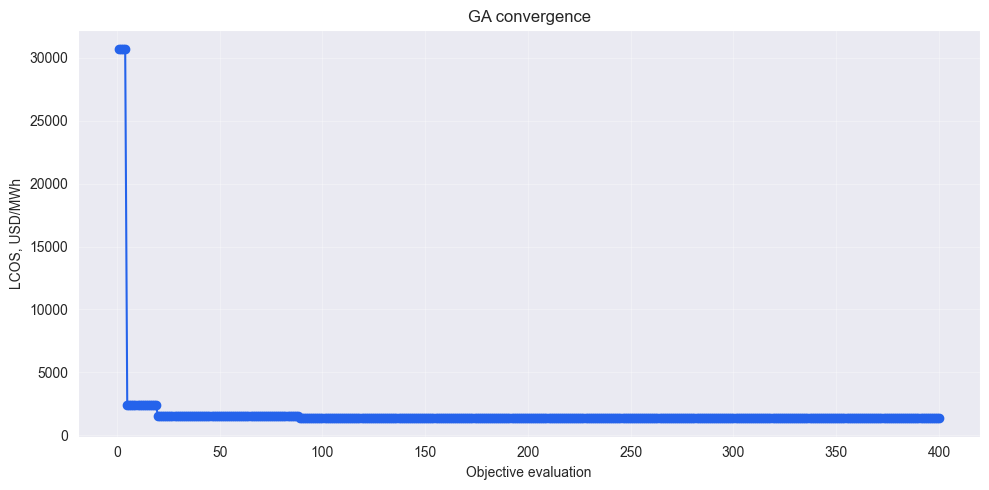

In [4]:
def run_genetic_optimization(data: pd.DataFrame, parameter_overrides: dict[str, Any] | None = None,
                             lower_capacity: int = 110, upper_capacity: int = 10_000,
                             population_size: int = 20, generations: int = 20,
                             seed: int = 1) -> tuple[Any, OptProblem]:
    """Run mixed-variable GA and return both result and tracked objective history."""
    from pymoo.algorithms.moo.nsga2 import RankAndCrowdingSurvival
    from pymoo.core.mixed import MixedVariableGA
    from pymoo.optimize import minimize

    if lower_capacity <= 0 or upper_capacity < lower_capacity:
        raise ValueError('Invalid capacity bounds')
    evaluator = build_evaluator(parameter_overrides)
    problem = OptProblem(
        objective=lambda design: evaluator.evaluate(design, data),
        lower_bound=lower_capacity,
        upper_bound=upper_capacity,
    )
    algorithm = MixedVariableGA(pop_size=population_size,
                                survival=RankAndCrowdingSurvival())
    result = minimize(problem, algorithm, termination=('n_gen', generations),
                      seed=seed, save_history=True)
    return result, problem

def plot_lcos_convergence(problem: OptProblem, output_path: Path | None = None) -> plt.Figure:
    """Plot best LCOS in USD/MWh for every objective evaluation."""
    if not problem.history_best_value:
        raise ValueError('Optimization history is empty')
    figure, axis = plt.subplots(figsize=(10, 5))
    values = np.asarray(problem.history_best_value) * 1e6 / 85
    axis.plot(np.arange(1, len(values) + 1), values, color='#2563EB', marker='o')
    axis.set(xlabel='Objective evaluation', ylabel='LCOS, USD/MWh',
             title='GA convergence')
    axis.grid(alpha=0.3)
    figure.tight_layout()
    if output_path is not None:
        figure.savefig(output_path, dpi=300, bbox_inches='tight')
    return figure

RUN_GA = True

if RUN_GA:
    ga_result, ga_problem = run_genetic_optimization(dataset)
    plot_lcos_convergence(ga_problem, PLOTS_DIRECTORY / 'lcos_convergence.png')
    plt.show()
else:
    ga_result, ga_problem = None, None
    print('GA disabled; set RUN_GA = True to generate lcos_convergence.')

In [10]:
ga_result.F[0]

np.float64(0.11455348222612777)

## 5. Расчёт оптимальной LCOS на сетке CAPEX

In [5]:
def find_optimal_lcos(data: pd.DataFrame, c_capex: float, p_capex: float,
                      population_size: int = 20, generations: int = 20,
                      seed: int = 1) -> dict[str, float]:
    """Find the best LCOS for one pair of energy and power CAPEX values."""
    _, problem = run_genetic_optimization(
        data, {'c_capex': c_capex, 'p_capex': p_capex},
        population_size=population_size, generations=generations, seed=seed,
    )
    if problem.best_parameters is None:
        raise RuntimeError('Optimization did not produce a feasible design')
    metrics = problem.history_best_metrics[-1]
    return {'c_capex': c_capex, 'p_capex': p_capex,
            'lcos_usd_mwh': float(problem.best_value * 1e6 / 85),
            'capacity': float(problem.best_parameters[0]),
            'power': float(problem.best_parameters[1]),
            'npv': float(metrics.get('npv_last', 0.0) or 0.0),
            'irr': float(metrics.get('irr', 0.0) or 0.0)}

def calculate_lcos_surface(data: pd.DataFrame, energy_capex_values: Sequence[float],
                           power_capex_values: Sequence[float], **optimization_kwargs: Any) -> pd.DataFrame:
    """Evaluate optimal LCOS for every point of an energy/power CAPEX grid."""
    records = []
    for power_capex in power_capex_values:
        for energy_capex in energy_capex_values:
            records.append(find_optimal_lcos(data, energy_capex, power_capex, **optimization_kwargs))
    return pd.DataFrame(records)

def plot_lcos_surface(surface: pd.DataFrame, output_path: Path | None = None) -> plt.Figure:
    """Render the optimal LCOS grid as a labelled heatmap."""
    table = surface.pivot(index='p_capex', columns='c_capex', values='lcos_usd_mwh')
    figure, axis = plt.subplots(figsize=(10, 7))
    sns.heatmap(table, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axis,
                cbar_kws={'label': 'Optimal LCOS, USD/MWh'})
    axis.set(xlabel='Energy CAPEX, USD/kWh', ylabel='Power CAPEX, USD/kW',
             title='Optimal LCOS surface')
    figure.tight_layout()
    if output_path is not None:
        figure.savefig(output_path, dpi=300, bbox_inches='tight')
    return figure

if RUN_SURFACE:
    surface = calculate_lcos_surface(
        dataset, energy_capex_values=np.linspace(75, 600, 6),
        power_capex_values=np.linspace(150, 2000, 6),
        population_size=20, generations=20, seed=1,
    )
    surface.to_csv(DATA_DIRECTORY / 'lcos_optimal_params.csv', index=False, encoding='utf-8-sig')
    plot_lcos_surface(surface, PLOTS_DIRECTORY / 'lcos_surface.png')
    plt.show()

## 6. `lcos_optimal_sensitivity`: влияние CAPEX на оптимальный проект

In [6]:
def plot_lcos_optimal_sensitivity(surface: pd.DataFrame, output_path: Path | None = None) -> plt.Figure:
    """Plot how the optimal capacity changes across the CAPEX grid."""
    table = surface.pivot(index='p_capex', columns='c_capex', values='capacity')
    figure, axis = plt.subplots(figsize=(10, 7))
    sns.heatmap(table, annot=True, fmt='.0f', cmap='viridis', ax=axis,
                cbar_kws={'label': 'Optimal capacity, kWh'})
    axis.set(xlabel='Energy CAPEX, USD/kWh', ylabel='Power CAPEX, USD/kW',
             title='Optimal battery capacity sensitivity')
    figure.tight_layout()
    if output_path is not None:
        figure.savefig(output_path, dpi=300, bbox_inches='tight')
    return figure

if RUN_SURFACE:
    plot_lcos_optimal_sensitivity(surface, PLOTS_DIRECTORY / 'lcos_optimal_sensitivity.png')
    plt.show()

## 7. `tornado_LCOS`: однопараметрический анализ чувствительности

In [8]:
SENSITIVITY_PARAMETERS = ('c_capex', 'p_capex', 'fuel_price', 'wacc', 'lifespan')

def calculate_tornado_sensitivity(data: pd.DataFrame, capacity: float, power: float,
                                   relative_change: float = 0.2,
                                   lifespan_change: int = 5) -> pd.DataFrame:
    """Calculate low/high LCOS after changing one economic parameter at a time."""
    if not 0 < relative_change < 1:
        raise ValueError('relative_change must be between 0 and 1')
    base = evaluate_design(capacity, power)
    rows = []
    for parameter in SENSITIVITY_PARAMETERS:
        base_value = BASE_PARAMETERS[parameter]
        if parameter == 'lifespan':
            low_value, high_value = max(1, base_value - lifespan_change), base_value + lifespan_change
        else:
            low_value, high_value = base_value * (1 - relative_change), base_value * (1 + relative_change)
        low = evaluate_design(capacity, power, data, {parameter: low_value})
        high = evaluate_design(capacity, power, data, {parameter: high_value})
        rows.append({'parameter': parameter, 'low_value': low_value, 'high_value': high_value,
                     'lcos_low': low.lcos, 'lcos_high': high.lcos, 'base_lcos': base.lcos})
    result = pd.DataFrame(rows)
    result['impact'] = (result['lcos_high'] - result['lcos_low']).abs()
    return result.sort_values('impact', ascending=False).reset_index(drop=True)

def plot_tornado_lcos(sensitivity: pd.DataFrame, output_path: Path | None = None) -> plt.Figure:
    """Render LCOS changes as a tornado chart around the base value."""
    if sensitivity.empty:
        raise ValueError('sensitivity must not be empty')
    base_lcos = sensitivity['base_lcos'].iloc[0]
    low_delta = (sensitivity['lcos_low'] - base_lcos) / base_lcos * 100
    high_delta = (sensitivity['lcos_high'] - base_lcos) / base_lcos * 100
    positions = np.arange(len(sensitivity))
    figure, axis = plt.subplots(figsize=(11, 6))
    axis.barh(positions, low_delta, color='#D7110D', label='Low parameter value')
    axis.barh(positions, high_delta, color='#4169E1', label='High parameter value')
    axis.axvline(0, color='black', linestyle='--')
    axis.set_yticks(positions, sensitivity['parameter'])
    axis.invert_yaxis()
    axis.set(xlabel='LCOS change from base, %', title=f'Tornado LCOS (base={base_lcos:.3g})')
    axis.grid(axis='x', alpha=0.3)
    axis.legend()
    figure.tight_layout()
    if output_path is not None:
        figure.savefig(output_path, dpi=300, bbox_inches='tight')
    return figure

if RUN_TORNADO:
    tornado = calculate_tornado_sensitivity(dataset, BASE_CAPACITY, BASE_POWER)
    tornado.to_csv(DATA_DIRECTORY / 'tornado_LCOS.csv', index=False, encoding='utf-8-sig')
    plot_tornado_lcos(tornado, PLOTS_DIRECTORY / 'tornado_LCOS.png')
    plt.show()

## 8. Ручной запуск полного набора графиков

In [9]:
# После проверки времени расчёта можно включить нужные флаги в блоке 1.
print('Available plots: lcos_convergence, lcos_surface, lcos_optimal_sensitivity, tornado_LCOS')

Available plots: lcos_convergence, lcos_surface, lcos_optimal_sensitivity, tornado_LCOS
